# Stage 3 — Zero-Shot Generalization Analysis (Forest)

This notebook evaluates the performance of the Stage 3 Neural LOD model (trained on the Baker scene) when deployed in the **Illustrated Nature (Forest)** environment.

### Objectives:
1. **Spatial Generalization**: Does the model cull based on local geometry (Forest density) or memorized coordinates (Baker positions)?
2. **Geometric Correlation**: Does `predicted_threshold` correlate with real scene complexity (`triangle_count`) in the new scene?
3. **LOD Stability**: Quantify high-frequency jitter in an unfamiliar environment.

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import os
import glob

# Premium Styling
plt.style.use('dark_background')
plt.rcParams.update({
    'font.family': 'sans-serif',
    'axes.facecolor': '#1a1a1a',
    'axes.edgecolor': '#404040',
    'grid.color': '#333333',
    'axes.labelcolor': '#e0e0e0',
    'xtick.color': '#808080',
    'ytick.color': '#808080',
    'font.size': 10
})

BLUE_GRADIENT = ['#00d4ff', '#0097ff', '#0058ff']
FIRE_GRADIENT = ['#ff4b2b', '#ff416c']

# Paths
BASE_DIR = Path("../../").resolve()
GEN_DATA_DIR = Path("../../data/Generalize_zero_shot")
BAKER_DATA_DIR = Path("../../data/Baker_Eval_3")
PLOT_DIR = Path("../../plots/Stage_3/Generalization")

PLOT_DIR.mkdir(parents=True, exist_ok=True)

print(f"✓ Paths synchronized. Base: {BASE_DIR}")

✓ Paths synchronized. Base: C:\Users\Gica\neural-lod\ml_pipeline


## 1. Data Ingestion

We load the generalization logs (Forest) and compare them against the Stage 3 baseline (Baker).

In [17]:
# Load Gen logs (picks the latest file)
gen_files = sorted(glob.glob(str(GEN_DATA_DIR / "inference_eval_*.csv")), key=os.path.getmtime)
if not gen_files:
    raise FileNotFoundError("No generalization logs found in data/Generalize_zero_shot!")

latest_gen = gen_files[-1]
df_forest = pd.read_csv(latest_gen)
print(f"✓ Loaded Forest logs: {len(df_forest)} frames from {Path(latest_gen).name}")
print(f"Columns found: {df_forest.columns.tolist() if df_forest is not None else 'None'}")

# Load Baker baseline for context (latest)
baker_files = sorted(glob.glob(str(BAKER_DATA_DIR / "inference_eval_*.csv")), key=os.path.getmtime)
if baker_files:
    latest_baker = baker_files[-1]
    df_baker = pd.read_csv(latest_baker)
    print(f"✓ Loaded Baker baseline: {len(df_baker)} frames from {Path(latest_baker).name}")
else:
    df_baker = None
    print("⚠ No Baker baseline found. Comparative analysis will be limited.")

✓ Loaded Forest logs: 3861 frames from inference_eval_Generaliz_Zero_20260403_000123.csv
Columns found: ['run_label', 'frame', 'cpu_ms', 'gpu_ms', 'fps', 'inference_duration_ms', 'predicted_t0', 'predicted_t1', 'predicted_t2', 'predicted_t3', 'predicted_threshold_mean', 'lod_bias_applied', 'threshold_changed', 'cam_pos_x', 'cam_pos_y', 'cam_pos_z', 'cam_rot_x', 'cam_rot_y', 'cam_rot_z', 'triangle_count', 'visible_renderer_count', 'screen_coverage', 'draw_call_count']
✓ Loaded Baker baseline: 3777 frames from inference_eval_neural_4thresh_20260402_235249.csv


## 2. Spatial Heatmaps & Overfitting Check

If the model Culled Based on **Coordiantes**, we would see culling patterns that match the Baker layout (e.g. gaps at (0,0)). 
If the model Culled Based on **Density**, the heatmap should correspond to the Forest geometry.

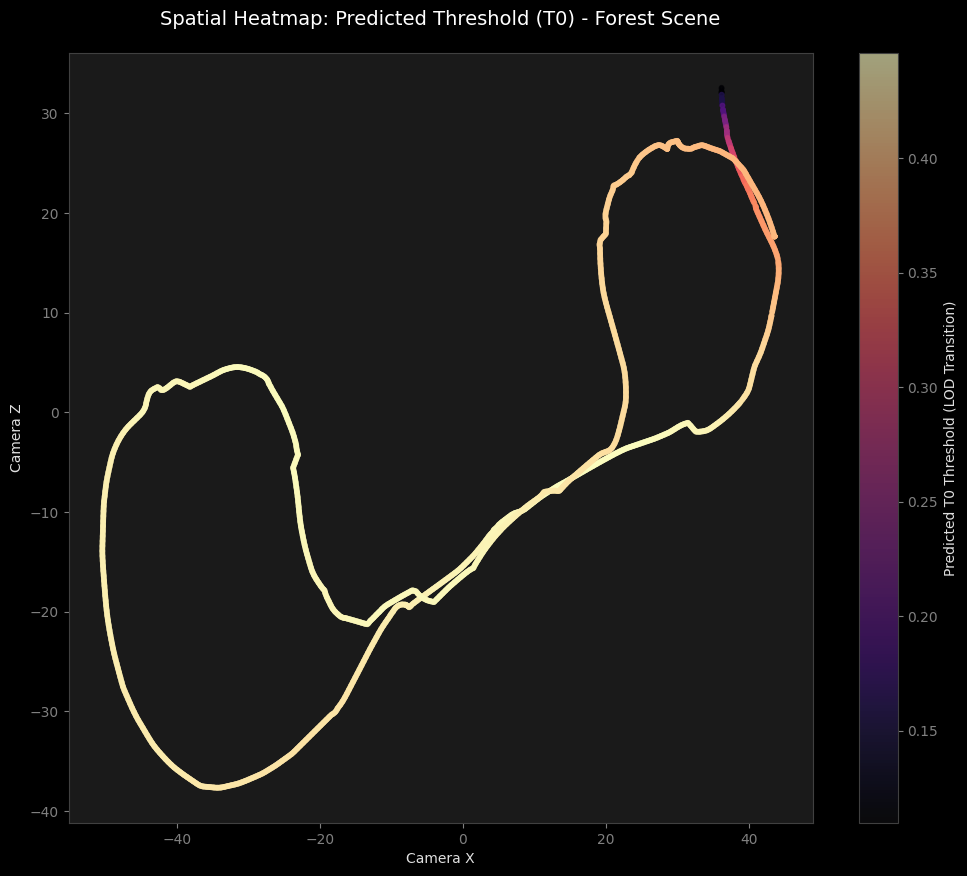

In [18]:
fig, ax = plt.subplots(1, 1, figsize=(12, 10))

# Plot Forest Culling Pattern
sc = ax.scatter(df_forest['cam_pos_x'], df_forest['cam_pos_z'], 
                c=df_forest['predicted_t0'], cmap='magma', s=10, alpha=0.6)
plt.colorbar(sc, label='Predicted T0 Threshold (LOD Transition)')
ax.set_title("Spatial Heatmap: Predicted Threshold (T0) - Forest Scene", color='white', pad=20, fontsize=14)
ax.set_xlabel("Camera X")
ax.set_ylabel("Camera Z")

plt.savefig(PLOT_DIR / "spatial_heatmap_generalization.png", dpi=300, bbox_inches='tight')
plt.show()

## 3. Correlation Analysis: Geometric Complexity

Does the model correctly lower the threshold (more aggressive LOD) when the `triangle_count` increases in a scene it has never seen?

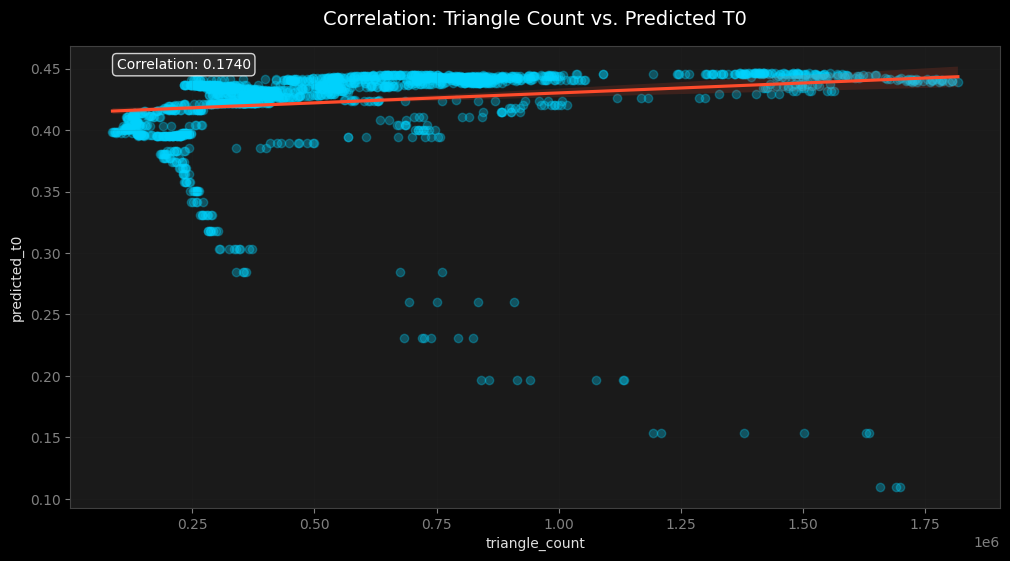

=== TRIANGLE COUNT vs PREDICTED T0 ===
triangle_count -> mean: 590849.7961667961 std: 390293.5801255582 min: 86256 max: 1851540
predicted_t0  -> mean: 0.42400335742035744 std: 0.03552326266299355 min: 0.109901 max: 0.446137

correlation: 0.17403131844949898


In [19]:
if 'triangle_count' in df_forest.columns:
    plt.figure(figsize=(12, 6))
    # Subsample for clarity if large
    df_sub = df_forest.sample(min(2000, len(df_forest)))
    
    sns.regplot(data=df_sub, x='triangle_count', y='predicted_t0', 
                scatter_kws={'alpha':0.3, 'color': BLUE_GRADIENT[0]}, 
                line_kws={'color': FIRE_GRADIENT[0]})
    
    plt.title("Correlation: Triangle Count vs. Predicted T0", fontsize=14, pad=15)
    plt.grid(alpha=0.1)
    
    correlation = df_forest['triangle_count'].corr(df_forest['predicted_t0'])
    plt.annotate(f"Correlation: {correlation:.4f}", xy=(0.05, 0.95), xycoords='axes fraction', 
                 color='white', bbox=dict(boxstyle="round", fc="#333333", alpha=0.8))
    
    plt.savefig(PLOT_DIR / "correlation_triangles_vs_threshold.png", dpi=300)
    plt.show()
else:
    print("⚠ 'triangle_count' column NOT FOUND. Skipping correlation analysis.")
    print("To enable this, ensure Complexity Logging is active in InferenceEvaluationLogger.cs.")

    # === TEXT SUMMARY ===
tri = df_forest['triangle_count']
t0  = df_forest['predicted_t0']

print("=== TRIANGLE COUNT vs PREDICTED T0 ===")
print("triangle_count -> mean:", tri.mean(), "std:", tri.std(), "min:", tri.min(), "max:", tri.max())
print("predicted_t0  -> mean:", t0.mean(),  "std:", t0.std(),  "min:", t0.min(),  "max:", t0.max())

print("\ncorrelation:", correlation)

## 4. Stability & Jitter Analysis

Measure the frequency of LOD flips in the Forest scene. High values indicate threshold instability.

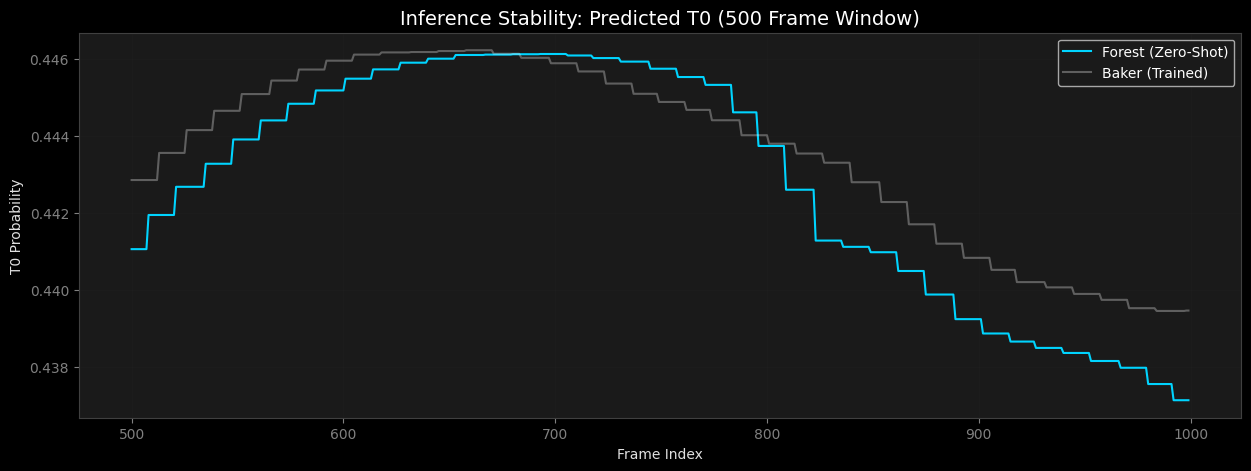

=== FOREST (Zero-Shot) ===
mean: 0.4428764560000001
std : 0.0030285818040051487
min : 0.437135
max : 0.446137

=== BAKER (Trained) ===
mean: 0.443655012
std : 0.0022966922219096694
min : 0.439456
max : 0.446235


In [20]:
plt.figure(figsize=(15, 5))
plt.plot(df_forest['frame'].iloc[500:1000], df_forest['predicted_t0'].iloc[500:1000], 
         color=BLUE_GRADIENT[0], label="Forest (Zero-Shot)")
if df_baker is not None:
    plt.plot(df_baker['frame'].iloc[500:1000], df_baker['predicted_t0'].iloc[500:1000], 
             color='white', alpha=0.3, label="Baker (Trained)")
             
plt.title("Inference Stability: Predicted T0 (500 Frame Window)", fontsize=14)
plt.xlabel("Frame Index")
plt.ylabel("T0 Probability")
plt.legend()
plt.grid(alpha=0.1)
plt.savefig(PLOT_DIR / "inference_stability_comparison.png", dpi=300)
plt.show()


# === TEXT SUMMARY ===
print("=== FOREST (Zero-Shot) ===")
forest_slice = df_forest['predicted_t0'].iloc[500:1000]
print("mean:", forest_slice.mean())
print("std :", forest_slice.std())
print("min :", forest_slice.min())
print("max :", forest_slice.max())

if df_baker is not None:
    print("\n=== BAKER (Trained) ===")
    baker_slice = df_baker['predicted_t0'].iloc[500:1000]
    print("mean:", baker_slice.mean())
    print("std :", baker_slice.std())
    print("min :", baker_slice.min())
    print("max :", baker_slice.max())